## 1. Подключение библиотек

In [6]:
import pandas as pd
import string
import re
import nltk
import pymorphy3

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem.snowball import SnowballStemmer


In [10]:
df =pd.read_csv("dataset_.csv")

In [11]:
df.head()

,NameCompany,Description,Raiting,DataPublish,Activity,TextArticle
0,red_mad_robot,NaN,117.94,6 часов назад,№1 в разработке цифровых решений для бизнеса,117.94 Рейтинг red_mad_robot №1 в разработке ц...
1,Cloud4Y,NaN,71.07,Автор оригинала: Yashwant Singh,#1 Корпоративный облачный провайдер,71.07 Рейтинг Cloud4Y #1 Корпоративный облачны...
2,Cloud4Y,NaN,71.07,Автор оригинала: Yashwant Singh,#1 Корпоративный облачный провайдер,71.07 Рейтинг Cloud4Y #1 Корпоративный облачны...
3,Southbridge,NaN,280.79,Автор оригинала: Seifeldin Mahjoub,Обеспечиваем стабильную работу highload-проектов,4.29 Оценка 280.79 Рейтинг Southbridge Обеспеч...
4,Альфа-Банк,NaN,404.32,Подписаться,Лучший мобильный банк по версии Markswebb,404.32 Рейтинг Альфа-Банк Лучший мобильный бан...


### Описание набора данных

__namecompany__ - наименование компании

__description__ - описание компании

__rating__ - рейтинг компании

__activity__ - сфера деятельности компаний

__date_publish__ - дата публикации статьи

__text_article__ - текст статьи

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   NameCompany  10 non-null     object 
 1   Description  0 non-null      float64
 2   Raiting      10 non-null     float64
 3   DataPublish  10 non-null     object 
 4   Activity     10 non-null     object 
 5   TextArticle  10 non-null     object 
dtypes: float64(2), object(4)
memory usage: 612.0+ bytes


## 2. Предварительная обработка данных

1. Перевод всех букв в тексте в нижний регистр
2. Удаление знаков препинания
3. Токенизация по словам
4. Удаление стоп слов
5. Стемминг (приведение слов к нормальной форме)
6. Лемматизация

In [13]:
def remove_punctuation(text): 
    return "".join([ch if ch not in string.punctuation else ' ' for ch in text])

def remove_numbers(text): 
    return ''.join([i if not i.isdigit() else ' ' for i in text])

def remove_multiple_spaces(text): 
    return re.sub(r'\s+', ' ', text, flags=re.I)

st = '❯\xa0—«»'
def remove_othersymbol(text):
    return ''.join([ch if ch not in st else ' ' for ch in text])

In [15]:
df['prep_text'] = [remove_multiple_spaces(remove_numbers(remove_othersymbol(remove_punctuation(text.lower())))) for text in df['TextArticle']]

In [16]:
df.head()

,NameCompany,Description,Raiting,DataPublish,Activity,TextArticle,prep_text
0,red_mad_robot,NaN,117.94,6 часов назад,№1 в разработке цифровых решений для бизнеса,117.94 Рейтинг red_mad_robot №1 в разработке ц...,рейтинг red mad robot № в разработке цифровых...
1,Cloud4Y,NaN,71.07,Автор оригинала: Yashwant Singh,#1 Корпоративный облачный провайдер,71.07 Рейтинг Cloud4Y #1 Корпоративный облачны...,рейтинг cloud y корпоративный облачный провай...
2,Cloud4Y,NaN,71.07,Автор оригинала: Yashwant Singh,#1 Корпоративный облачный провайдер,71.07 Рейтинг Cloud4Y #1 Корпоративный облачны...,рейтинг cloud y корпоративный облачный провай...
3,Southbridge,NaN,280.79,Автор оригинала: Seifeldin Mahjoub,Обеспечиваем стабильную работу highload-проектов,4.29 Оценка 280.79 Рейтинг Southbridge Обеспеч...,оценка рейтинг southbridge обеспечиваем стаби...
4,Альфа-Банк,NaN,404.32,Подписаться,Лучший мобильный банк по версии Markswebb,404.32 Рейтинг Альфа-Банк Лучший мобильный бан...,рейтинг альфа банк лучший мобильный банк по в...


In [18]:
df['TextArticle'][0]

'117.94 Рейтинг red_mad_robot №1 в разработке цифровых решений для бизнеса  6 часов назад Средний18 мин redmadrobot Cocoapods, Carthage, SPM: как выбрать менеджер зависимостей в iOS 179 Блог компании red_mad_robot ,  Разработка под iOS* FAQ КАК СТАТЬ АВТОРОМ Старший iOS-разработчик red_mad_robot Аня Кочешкова рассказывает, чем отличаются три менеджера зависимостей, в каких случаях и для каких задач подойдёт тот или иной. Материал будет полезен джун-специалистам, которые только начали погружаться в разработку: специально для них подробно объясняем, что такое семантическое версионирование, как устроены модули кода и в чём разница между динамическими и статическими библиотеками. Что такое менеджер зависимостей и зачем он нужен В современной разработке зависимость — это написанный кем-то другим код, который используется в вашей программе. Добавление зависимости позволяет воспользоваться уже сделанной кем-то хорошей работой и избежать «изобретения велосипеда», а также лишних действий: проек

In [19]:
df['prep_text'][0]

' рейтинг red mad robot № в разработке цифровых решений для бизнеса часов назад средний мин redmadrobot cocoapods carthage spm как выбрать менеджер зависимостей в ios блог компании red mad robot разработка под ios faq как стать автором старший ios разработчик red mad robot аня кочешкова рассказывает чем отличаются три менеджера зависимостей в каких случаях и для каких задач подойдёт тот или иной материал будет полезен джун специалистам которые только начали погружаться в разработку специально для них подробно объясняем что такое семантическое версионирование как устроены модули кода и в чём разница между динамическими и статическими библиотеками что такое менеджер зависимостей и зачем он нужен в современной разработке зависимость это написанный кем то другим код который используется в вашей программе добавление зависимости позволяет воспользоваться уже сделанной кем то хорошей работой и избежать изобретения велосипеда а также лишних действий проектирования написания тестирования отладк

In [20]:
russian_stopwords = stopwords.words("russian") 

In [21]:
russian_stopwords 

['и',
 'в',
 'во',
 'не',
 'что',
 'он',
 'на',
 'я',
 'с',
 'со',
 'как',
 'а',
 'то',
 'все',
 'она',
 'так',
 'его',
 'но',
 'да',
 'ты',
 'к',
 'у',
 'же',
 'вы',
 'за',
 'бы',
 'по',
 'только',
 'ее',
 'мне',
 'было',
 'вот',
 'от',
 'меня',
 'еще',
 'нет',
 'о',
 'из',
 'ему',
 'теперь',
 'когда',
 'даже',
 'ну',
 'вдруг',
 'ли',
 'если',
 'уже',
 'или',
 'ни',
 'быть',
 'был',
 'него',
 'до',
 'вас',
 'нибудь',
 'опять',
 'уж',
 'вам',
 'ведь',
 'там',
 'потом',
 'себя',
 'ничего',
 'ей',
 'может',
 'они',
 'тут',
 'где',
 'есть',
 'надо',
 'ней',
 'для',
 'мы',
 'тебя',
 'их',
 'чем',
 'была',
 'сам',
 'чтоб',
 'без',
 'будто',
 'чего',
 'раз',
 'тоже',
 'себе',
 'под',
 'будет',
 'ж',
 'тогда',
 'кто',
 'этот',
 'того',
 'потому',
 'этого',
 'какой',
 'совсем',
 'ним',
 'здесь',
 'этом',
 'один',
 'почти',
 'мой',
 'тем',
 'чтобы',
 'нее',
 'сейчас',
 'были',
 'куда',
 'зачем',
 'всех',
 'никогда',
 'можно',
 'при',
 'наконец',
 'два',
 'об',
 'другой',
 'хоть',
 'после',
 'на

In [22]:
russian_stopwords.extend(['т.д.', 'т', 'д', 'это','который','с','своём','всем','наш', 'свой']) 

In [23]:
def tokenize(text):
    t = word_tokenize(text)
    tokens = [token for token in t if token not in russian_stopwords]
    text = " ".join(tokens)
    return text

In [26]:
df['tokenize_text'] = [tokenize(text) for text in df['prep_text']]

In [27]:
df.head()

,NameCompany,Description,Raiting,DataPublish,Activity,TextArticle,prep_text,tokenize_text
0,red_mad_robot,NaN,117.94,6 часов назад,№1 в разработке цифровых решений для бизнеса,117.94 Рейтинг red_mad_robot №1 в разработке ц...,рейтинг red mad robot № в разработке цифровых...,рейтинг red mad robot № разработке цифровых ре...
1,Cloud4Y,NaN,71.07,Автор оригинала: Yashwant Singh,#1 Корпоративный облачный провайдер,71.07 Рейтинг Cloud4Y #1 Корпоративный облачны...,рейтинг cloud y корпоративный облачный провай...,рейтинг cloud y корпоративный облачный провайд...
2,Cloud4Y,NaN,71.07,Автор оригинала: Yashwant Singh,#1 Корпоративный облачный провайдер,71.07 Рейтинг Cloud4Y #1 Корпоративный облачны...,рейтинг cloud y корпоративный облачный провай...,рейтинг cloud y корпоративный облачный провайд...
3,Southbridge,NaN,280.79,Автор оригинала: Seifeldin Mahjoub,Обеспечиваем стабильную работу highload-проектов,4.29 Оценка 280.79 Рейтинг Southbridge Обеспеч...,оценка рейтинг southbridge обеспечиваем стаби...,оценка рейтинг southbridge обеспечиваем стабил...
4,Альфа-Банк,NaN,404.32,Подписаться,Лучший мобильный банк по версии Markswebb,404.32 Рейтинг Альфа-Банк Лучший мобильный бан...,рейтинг альфа банк лучший мобильный банк по в...,рейтинг альфа банк лучший мобильный банк верси...


In [28]:
df['tokenize_text'][0]

'рейтинг red mad robot № разработке цифровых решений бизнеса часов назад средний мин redmadrobot cocoapods carthage spm выбрать менеджер зависимостей ios блог компании red mad robot разработка ios faq стать автором старший ios разработчик red mad robot аня кочешкова рассказывает отличаются менеджера зависимостей каких случаях каких задач подойдёт иной материал полезен джун специалистам которые начали погружаться разработку специально подробно объясняем такое семантическое версионирование устроены модули кода чём разница динамическими статическими библиотеками такое менеджер зависимостей нужен современной разработке зависимость написанный кем другим код используется вашей программе добавление зависимости позволяет воспользоваться сделанной кем хорошей работой избежать изобретения велосипеда также лишних действий проектирования написания тестирования отладки поддержки определённой логики такие куски логики называют пакетами библиотеками модулями сложнее проект сторонних библиотек правда 

In [29]:
stemmer = SnowballStemmer("russian")

stem_list = []
for text in (df['tokenize_text']):
    try:
        tokens = word_tokenize(text)
        res = list()
        for word in tokens:
            p = stemmer.stem(word)
            res.append(p)
        text = " ".join(res)
        stem_list.append(text)
    except Exception as e:
        print(e)
        
df['text_stem'] = stem_list

In [30]:
df.head()

,NameCompany,Description,Raiting,DataPublish,Activity,TextArticle,prep_text,tokenize_text,text_stem
0,red_mad_robot,NaN,117.94,6 часов назад,№1 в разработке цифровых решений для бизнеса,117.94 Рейтинг red_mad_robot №1 в разработке ц...,рейтинг red mad robot № в разработке цифровых...,рейтинг red mad robot № разработке цифровых ре...,рейтинг red mad robot № разработк цифров решен...
1,Cloud4Y,NaN,71.07,Автор оригинала: Yashwant Singh,#1 Корпоративный облачный провайдер,71.07 Рейтинг Cloud4Y #1 Корпоративный облачны...,рейтинг cloud y корпоративный облачный провай...,рейтинг cloud y корпоративный облачный провайд...,рейтинг cloud y корпоративн облачн провайдер а...
2,Cloud4Y,NaN,71.07,Автор оригинала: Yashwant Singh,#1 Корпоративный облачный провайдер,71.07 Рейтинг Cloud4Y #1 Корпоративный облачны...,рейтинг cloud y корпоративный облачный провай...,рейтинг cloud y корпоративный облачный провайд...,рейтинг cloud y корпоративн облачн провайдер а...
3,Southbridge,NaN,280.79,Автор оригинала: Seifeldin Mahjoub,Обеспечиваем стабильную работу highload-проектов,4.29 Оценка 280.79 Рейтинг Southbridge Обеспеч...,оценка рейтинг southbridge обеспечиваем стаби...,оценка рейтинг southbridge обеспечиваем стабил...,оценк рейтинг southbridge обеспечива стабильн ...
4,Альфа-Банк,NaN,404.32,Подписаться,Лучший мобильный банк по версии Markswebb,404.32 Рейтинг Альфа-Банк Лучший мобильный бан...,рейтинг альфа банк лучший мобильный банк по в...,рейтинг альфа банк лучший мобильный банк верси...,рейтинг альф банк лучш мобильн банк верс marks...


In [31]:
df['text_stem'][0]

'рейтинг red mad robot № разработк цифров решен бизнес час назад средн мин redmadrobot cocoapods carthage spm выбра менеджер зависим ios блог компан red mad robot разработк ios faq стат автор старш ios разработчик red mad robot ан кочешков рассказыва отлича менеджер зависим как случа как задач подойдет ин материа полез джун специалист котор нача погружа разработк специальн подробн объясня так семантическ версионирован устро модул код чем разниц динамическ статическ библиотек так менеджер зависим нуж современ разработк зависим написа кем друг код использ ваш программ добавлен зависим позволя воспользова сдела кем хорош работ избежа изобретен велосипед такж лишн действ проектирован написан тестирован отладк поддержк определен логик так куск логик называ пакет библиотек модул сложн проект сторон библиотек правд некотор приложен могут вообщ отказыва использован эт библиотек разн верс могут ссыла друг друг накладыва ограничен верс работ проиллюстрирова так бытов пример телефон показа погод 

In [32]:
morph = pymorphy3.MorphAnalyzer(lang='ru')

In [33]:
%%time
lemm_texts_list = []
for text in (df['tokenize_text']):
    try:
        tokens = word_tokenize(text)
        res = list()
        for word in tokens:
            p = morph.parse(word)[0]
            res.append(p.normal_form)
        text = " ".join(res)
        lemm_texts_list.append(text)
    except Exception as e:
        print(e)
    
df['text_lemm'] = lemm_texts_list

CPU times: total: 3.31 s
Wall time: 3.3 s


In [34]:
df.head()

,NameCompany,Description,Raiting,DataPublish,Activity,TextArticle,prep_text,tokenize_text,text_stem,text_lemm
0,red_mad_robot,NaN,117.94,6 часов назад,№1 в разработке цифровых решений для бизнеса,117.94 Рейтинг red_mad_robot №1 в разработке ц...,рейтинг red mad robot № в разработке цифровых...,рейтинг red mad robot № разработке цифровых ре...,рейтинг red mad robot № разработк цифров решен...,рейтинг red mad robot № разработка цифровой ре...
1,Cloud4Y,NaN,71.07,Автор оригинала: Yashwant Singh,#1 Корпоративный облачный провайдер,71.07 Рейтинг Cloud4Y #1 Корпоративный облачны...,рейтинг cloud y корпоративный облачный провай...,рейтинг cloud y корпоративный облачный провайд...,рейтинг cloud y корпоративн облачн провайдер а...,рейтинг cloud y корпоративный облачный провайд...
2,Cloud4Y,NaN,71.07,Автор оригинала: Yashwant Singh,#1 Корпоративный облачный провайдер,71.07 Рейтинг Cloud4Y #1 Корпоративный облачны...,рейтинг cloud y корпоративный облачный провай...,рейтинг cloud y корпоративный облачный провайд...,рейтинг cloud y корпоративн облачн провайдер а...,рейтинг cloud y корпоративный облачный провайд...
3,Southbridge,NaN,280.79,Автор оригинала: Seifeldin Mahjoub,Обеспечиваем стабильную работу highload-проектов,4.29 Оценка 280.79 Рейтинг Southbridge Обеспеч...,оценка рейтинг southbridge обеспечиваем стаби...,оценка рейтинг southbridge обеспечиваем стабил...,оценк рейтинг southbridge обеспечива стабильн ...,оценка рейтинг southbridge обеспечивать стабил...
4,Альфа-Банк,NaN,404.32,Подписаться,Лучший мобильный банк по версии Markswebb,404.32 Рейтинг Альфа-Банк Лучший мобильный бан...,рейтинг альфа банк лучший мобильный банк по в...,рейтинг альфа банк лучший мобильный банк верси...,рейтинг альф банк лучш мобильн банк верс marks...,рейтинг альфа банк хороший мобильный банк верс...


In [35]:
df['text_lemm'][0]

'рейтинг red mad robot № разработка цифровой решение бизнес час назад средний мина redmadrobot cocoapods carthage spm выбрать менеджер зависимость ios блог компания red mad robot разработка ios faq стать автор старший ios разработчик red mad robot аня кочешкова рассказывать отличаться менеджер зависимость какой случай какой задача подойти иной материал полезный джуна специалист который начать погружаться разработка специально подробно объяснять такой семантический версионирование устроить модуль код что разница динамический статический библиотека такой менеджер зависимость нужный современный разработка зависимость написать кто другой код использоваться ваш программа добавление зависимость позволять воспользоваться сделать кто хороший работа избежать изобретение велосипед также лишний действие проектирование написание тестирование отладка поддержка определённый логика такой кусок логика называть пакет библиотека модуль сложный проект сторонний библиотека правда некоторый приложение мочь

In [36]:
df['text_lemm'] = [tokenize(text) for text in df['text_lemm']]

In [37]:
df.head()

,NameCompany,Description,Raiting,DataPublish,Activity,TextArticle,prep_text,tokenize_text,text_stem,text_lemm
0,red_mad_robot,NaN,117.94,6 часов назад,№1 в разработке цифровых решений для бизнеса,117.94 Рейтинг red_mad_robot №1 в разработке ц...,рейтинг red mad robot № в разработке цифровых...,рейтинг red mad robot № разработке цифровых ре...,рейтинг red mad robot № разработк цифров решен...,рейтинг red mad robot № разработка цифровой ре...
1,Cloud4Y,NaN,71.07,Автор оригинала: Yashwant Singh,#1 Корпоративный облачный провайдер,71.07 Рейтинг Cloud4Y #1 Корпоративный облачны...,рейтинг cloud y корпоративный облачный провай...,рейтинг cloud y корпоративный облачный провайд...,рейтинг cloud y корпоративн облачн провайдер а...,рейтинг cloud y корпоративный облачный провайд...
2,Cloud4Y,NaN,71.07,Автор оригинала: Yashwant Singh,#1 Корпоративный облачный провайдер,71.07 Рейтинг Cloud4Y #1 Корпоративный облачны...,рейтинг cloud y корпоративный облачный провай...,рейтинг cloud y корпоративный облачный провайд...,рейтинг cloud y корпоративн облачн провайдер а...,рейтинг cloud y корпоративный облачный провайд...
3,Southbridge,NaN,280.79,Автор оригинала: Seifeldin Mahjoub,Обеспечиваем стабильную работу highload-проектов,4.29 Оценка 280.79 Рейтинг Southbridge Обеспеч...,оценка рейтинг southbridge обеспечиваем стаби...,оценка рейтинг southbridge обеспечиваем стабил...,оценк рейтинг southbridge обеспечива стабильн ...,оценка рейтинг southbridge обеспечивать стабил...
4,Альфа-Банк,NaN,404.32,Подписаться,Лучший мобильный банк по версии Markswebb,404.32 Рейтинг Альфа-Банк Лучший мобильный бан...,рейтинг альфа банк лучший мобильный банк по в...,рейтинг альфа банк лучший мобильный банк верси...,рейтинг альф банк лучш мобильн банк верс marks...,рейтинг альфа банк хороший мобильный банк верс...


# Облако слов

In [38]:
pip install WordCloud

Note: you may need to restart the kernel to use updated packages.


In [39]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt
%matplotlib inline

In [40]:
# Получение текстовой строки из списка слов
def str_corpus(corpus):
    str_corpus = ''
    for i in corpus:
        str_corpus += ' ' + i
    str_corpus = str_corpus.strip()
    return str_corpus

# Получение списка всех слов в корпусе
def get_corpus(data):
    corpus = []
    for phrase in data:
        for word in phrase.split():
            corpus.append(word)
    return corpus

# Получение облака слов
def get_wordCloud(corpus):
    wordCloud = WordCloud(background_color='white',
                              stopwords=STOPWORDS,
                              width=3000,
                              height=2500,
                              max_words=200,
                              random_state=42
                         ).generate(str_corpus(corpus))
    return wordCloud

In [42]:
corpus = get_corpus(df['TextArticle'].values)
procWordCloud = get_wordCloud(corpus)

fig = plt.figure(figsize=(20, 8))
plt.subplot(1, 2, 1)
plt.imshow(procWordCloud)
plt.axis('off')
plt.subplot(1, 2, 1)

<Axes: >

In [43]:
corpus = get_corpus(df['text_lemm'].values)
procWordCloud = get_wordCloud(corpus)

fig = plt.figure(figsize=(20, 8))
plt.subplot(1, 2, 1)
plt.imshow(procWordCloud)
plt.axis('off')
plt.subplot(1, 2, 1)

<Axes: >

In [44]:
# Получение облака слов
def get_wordCloud2(corpus):
    wordCloud = WordCloud(background_color='white',
                              stopwords=STOPWORDS,
                              width=3000,
                              height=2500,
                              max_words=200,
                              random_state=42
                         ).generate(corpus)
    return wordCloud

In [45]:
corpus = df['text_lemm'][0]
procWordCloud = get_wordCloud2(corpus)

fig = plt.figure(figsize=(20, 8))
plt.subplot(1, 2, 1)
plt.imshow(procWordCloud)
plt.axis('off')
plt.subplot(1, 2, 1)

<Axes: >

In [46]:
corpus = df['text_lemm'][1]
procWordCloud = get_wordCloud2(corpus)

fig = plt.figure(figsize=(20, 8))
plt.subplot(1, 2, 1)
plt.imshow(procWordCloud)
plt.axis('off')
plt.subplot(1, 2, 1)

<Axes: >

In [48]:
df['text_lemm'][1]

'рейтинг cloud y корпоративный облачный провайдер автор оригинал yashwant singh взлом instagram ‑аккаунт популярный запрос поисковик поэтому смысл рассказать обычно работать просто знать откуда пойти атака cloud y час назад osint hacking работать фишинга нельзяграм простой мина k блог компания cloud y информационный безопасность социальный сеть сообщество обзор перевод стать автор начать попытка заполучить доступ аккаунт должный знать ник человек пытаться взломать небольшой разведка очень кстати увлекаться существовать различный инструмент разведка первый очередь поиск пользователь конкретный соцсеть цель узнать ник найти отличный инструмент название slash использовать поиск любой учётный запись пользователь везде регистрироваться ник ставить slash git clone https github com theahmadov slash cd slash pip install r requirements txt python slash py help проверить slash посмотреть результат некоторый учётный запись перечисленный создать год назад slash простой консольный инструмент также 

In [49]:
corpus = df['text_lemm'][2]
procWordCloud = get_wordCloud2(corpus)

fig = plt.figure(figsize=(20, 8))
plt.subplot(1, 2, 1)
plt.imshow(procWordCloud)
plt.axis('off')
plt.subplot(1, 2, 1)

<Axes: >

In [50]:
df['text_lemm'][2]

'рейтинг cloud y корпоративный облачный провайдер автор оригинал yashwant singh взлом instagram аккаунт популярный запрос поисковик поэтому смысл рассказать обычно работать просто знать откуда пойти атака час назад простой мина cloud y osint hacking работать фишинга нельзяграм k блог компания cloud y информационный безопасность социальный сеть сообщесть обзор перевод стать автор начать попытка заполучить доступ аккаунт должный знать ник человек пытаться взломать небольшой разведка очень кстати увлекаться существовать различный инструмент разведка первый очередь поиск пользователь конкретный соцсеть цель узнать ник найти отличный инструмент название slash использовать поиск любой учётный запись пользователь везде регистрироваться ник ставить slash проверить slash посмотреть результат некоторый учётный запись перечисленный создать год назад git clone https github com theahmadov slash cd slash pip install r requirements txt python slash py help slash простой консольный инструмент также мо

# Векторизация текстовых данных

Векторизация текста или преобразование текста в численную форму. Алгоритмы машинного обучения не умеют работать с текстом, поэтому необходимо превратить текст в цифры.

1. Прямое кодирование (one-hot encoding) 

Прямое кодирование (one-hot encoding) считается самым простым способом преобразования токенов в тензоры и выполняется следующим образом:

1. каждый токен представляет бинарный вектор (значения 0 или 1);
2. единица ставится тому элементу, который соответствует номеру токена в словаре.

Проблемой прямого кодирования является размерность. 

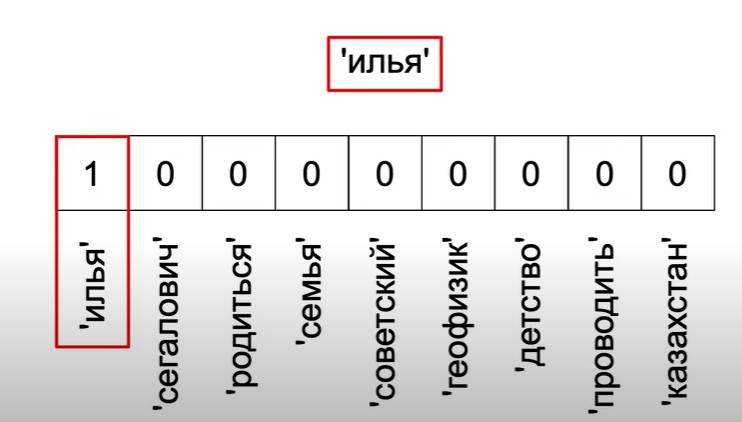

2. Bag of words

В отличие от прямого кодирования, мешок слов (Bag of words) выделяет вектору весь документ, и каждый элемент кодируется 1 по порядку следования слов в словаре.

Bag of words решает проблему размерности по одной оси. Количество строк определяется количеством документов. Однако, этот метод не учитывает важность того или иного токена, ведь одно слово может повторятся по несколько раз.

__Мешок слов__ - решает проблему размерности по одной оси. Количество строк определяется количеством документов. Однако, этот метод не учитывает важность того или иного токена, ведь одно слово может повторятся по несколько раз. В пакете scikit-learn есть модуль CountVectorizer, который преобразовывает входной текст в матрицу, значениями которой являются количества вхождения данного ключа(слова) в текст. Таким образом, мы получим матрицу, размерность которой будет равна количеству всех слов, умноженных на количество документов. И элементами матрицы будут числа, которые означают, сколько раз всего слово встретилось в тексте.

In [51]:
from sklearn.feature_extraction.text import CountVectorizer

In [52]:
df['text_lemm'][0]

'рейтинг red mad robot № разработка цифровой решение бизнес час назад средний мина redmadrobot cocoapods carthage spm выбрать менеджер зависимость ios блог компания red mad robot разработка ios faq стать автор старший ios разработчик red mad robot аня кочешкова рассказывать отличаться менеджер зависимость случай задача подойти иной материал полезный джуна специалист начать погружаться разработка специально подробно объяснять семантический версионирование устроить модуль код разница динамический статический библиотека менеджер зависимость нужный современный разработка зависимость написать код использоваться ваш программа добавление зависимость позволять воспользоваться сделать хороший работа избежать изобретение велосипед также лишний действие проектирование написание тестирование отладка поддержка определённый логика кусок логика называть пакет библиотека модуль сложный проект сторонний библиотека правда некоторый приложение мочь вообще отказываться использование библиотека разный верс

In [53]:
vectorizer = CountVectorizer()
vectorizer.fit(df['text_lemm'])

CountVectorizer()

In [101]:
print(vectorizer.vocabulary_)

{'блог': 16056, 'рассмотреть': 33935, 'устройство': 39132, 'назначение': 26026, 'контроллер': 23438, 'norvi': 8612, 'обойти': 27618, 'внимание': 17100, 'оказаться': 28059, 'линейка': 24259, 'gsm': 5317, 'иметь': 21656, 'соответствующий': 36349, 'модуль': 25517, 'борт': 16183, 'понимать': 31128, 'наличие': 26104, 'являться': 41247, 'существенный': 37350, 'дополнение': 19835, 'значительно': 21328, 'расширять': 34036, 'возможность': 17222, 'посылать': 31429, 'принимать': 32235, 'информационный': 21984, 'управлять': 38966, 'sms': 11861, 'организовать': 28385, 'резервный': 34230, 'независимый': 26609, 'ваш': 16534, 'iot': 6253, 'инфраструктура': 21994, 'канал': 22392, 'связь': 35175, 'статья': 36894, 'модель': 25486, 'ae': 201, 'кроме': 23871, 'esp': 3948, 'содержать': 36232, 'цифровой': 40185, 'аналоговый': 15124, 'вход': 17631, 'интерфейс': 21932, 'rs': 10951, 'прочий': 33088, 'делать': 19162, 'интересный': 21910, 'решение': 34495, 'создание': 36256, 'проект': 32635, 'автоматизация': 1473

In [103]:
vectorizer = CountVectorizer(analyzer='word', stop_words=russian_stopwords, ngram_range=(1, 3), min_df=2)
count_matrix = vectorizer.fit_transform(df['text_lemm'])

In [105]:
count_matrix.shape

(438, 61806)

In [107]:
vectorizer.get_feature_names_out()[45000:46000]

array(['процессор оперативный', 'процессор оперативный память',
       'процессор память', 'процессор получить',
       'процессор получить проектный', 'процессорный',
       'процессорный время', 'проч', 'прочее', 'прочее мочь', 'прочесть',
       'прочий', 'прочий интересный', 'прочий интересный штука',
       'прочий использовать', 'прочий нюанс', 'прочий опция',
       'прочий радость', 'прочий сложный', 'прочитать',
       'прочитать документация', 'прочитать запомнить', 'прочитать книга',
       'прочитать ограничение', 'прочитать самый', 'прочитать сообщение',
       'прочитать статья', 'прочить', 'прочно', 'прочность', 'прочный',
       'прочтение', 'прочувствовать', 'прошедшее', 'прошедшее время',
       'прошедшее год', 'прошедший', 'прошествие', 'прошивка',
       'прошивка микроконтроллер', 'прошивка определить',
       'прошивка устройство', 'прошить', 'прошлое', 'прошлое год',
       'прошлое использование', 'прошлое использование iso', 'прошлый',
       'прошлый век', 'п

In [119]:
vectorizer.get_feature_names_out()[3087]

'gsm'

In [121]:
vectorizer.get_feature_names_out()[25765]

'контроллер'

In [109]:
print(count_matrix)

  (0, 10244)	1
  (0, 47295)	2
  (0, 58075)	3
  (0, 29458)	3
  (0, 25765)	29
  (0, 32805)	1
  (0, 12235)	1
  (0, 33834)	1
  (0, 26685)	5
  (0, 3087)	33
  (0, 21267)	8
  (0, 52704)	3
  (0, 28449)	16
  (0, 10525)	3
  (0, 39921)	1
  (0, 29642)	4
  (0, 61549)	2
  (0, 54749)	1
  (0, 17726)	2
  (0, 20583)	4
  (0, 47441)	2
  (0, 12450)	4
  (0, 40689)	1
  (0, 42743)	1
  (0, 22105)	1
  :	:
  (437, 34722)	1
  (437, 20488)	2
  (437, 56674)	1
  (437, 22215)	1
  (437, 43292)	1
  (437, 43293)	1
  (437, 11900)	1
  (437, 57936)	1
  (437, 16946)	1
  (437, 42391)	1
  (437, 39565)	1
  (437, 53495)	1
  (437, 11826)	1
  (437, 42392)	1
  (437, 12589)	1
  (437, 31444)	1
  (437, 20047)	1
  (437, 17920)	1
  (437, 20885)	1
  (437, 20147)	1
  (437, 59274)	1
  (437, 39160)	1
  (437, 23085)	1
  (437, 33274)	1
  (437, 53222)	1


3. TF-IDF

TF-IDF (от англ. TF — term frequency, IDF — inverse document frequency) — статистическая мера, используемая для оценки важности слова в контексте документа, являющегося частью коллекции документов или корпуса. Вес некоторого слова пропорционален частоте употребления этого слова в документе и обратно пропорционален частоте употребления слова во всех документах коллекции.

TF-IDF состоит из двух компонентов: Term Frequency (частотность слова в документе) и Inverse Document Frequency (инверсия частоты документа). Они считаются следующим образом:

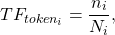

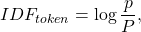

где n_i — сколько раз встречается токен в i-ом документе,  
N_i — общее количество токенов в i-ом документе,   
p — количество документов, в которых встречается токен,   
P — общее количеств документов.   
В конечном счете, TF-IDF – это произведение TF на IDF

 В TF-IDF редкие слова и слова, которые встречаются во всех документах, несут мало информации. 

__TF-IDF__ - это способ векторизации текста, отражающий важность слова в документе, а не только частоту его появления. В тексте большого объема некоторые слова могут присутствовать очень часто, но при этом не нести никакой значимой информации о фактическом содержании текста (документа). Если такие данные передавать непосредственно классификатору, то такие частые термины могут затенять частоты более редких, но при этом более интересных терминов. Для того, чтобы этого избежать, достаточно разделить количество употреблений каждого слова в документе на общее количество слов в документе, это есть TF — частота термина. Термин IDF (inverse document frequency) обозначает обратную частоту термина (инверсия частоты) с которой некоторое слово встречается в документах. IDF позволяет измерить непосредственную важность термина.


In [123]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [125]:
tfidf_vectorizer = TfidfVectorizer(max_df=0.8, max_features=10000,
                                 min_df=0.01, stop_words=russian_stopwords,
                                 ngram_range=(1,3))

In [127]:
%%time
tfidf_matrix = tfidf_vectorizer.fit_transform(df['text_lemm'])

CPU times: total: 3.59 s
Wall time: 6.74 s


In [128]:
tfidf_matrix.shape

(438, 10000)

In [131]:
tfidf_vectorizer.get_feature_names_out()[:100]

array(['ab', 'about', 'above', 'ac', 'access', 'account', 'accuracy',
       'action', 'actions', 'active', 'active directory', 'activity',
       'ad', 'adam', 'add', 'address', 'admin', 'adobe', 'advanced',
       'aes', 'af', 'after', 'age', 'agent', 'agile', 'ai', 'ajax', 'aka',
       'alert', 'aliexpress', 'all', 'allow', 'alpha', 'alpine', 'also',
       'alt', 'always', 'am', 'amazon', 'amd', 'an', 'analysis',
       'analystкурс', 'analystкурс математик',
       'analystкурс математик data', 'analytics', 'and', 'and the',
       'android', 'android ios', 'android разработчикjava',
       'android разработчикjava профессия', 'angular', 'annotation',
       'another', 'ansible', 'answer', 'any', 'apache', 'apache kafka',
       'api', 'api позволять', 'apiversion', 'app', 'append', 'apple',
       'application', 'applications', 'applied', 'apply', 'apps', 'apt',
       'ar', 'architect', 'architecture', 'arduino', 'are', 'args', 'arm',
       'arr', 'array', 'arxiv', 'as', 'asci

In [135]:
tfidf_vectorizer.get_feature_names_out()[1253]

'sim карта'

In [139]:
tfidf_vectorizer.get_feature_names_out()[5866]

'официальный документация'

In [133]:
print(tfidf_matrix)

  (0, 8936)	0.017094516609518867
  (0, 2201)	0.01892062986156212
  (0, 1830)	0.011880220186908014
  (0, 5214)	0.015414334927271772
  (0, 4879)	0.015414334927271772
  (0, 4818)	0.014799999982154434
  (0, 6447)	0.01836956784323826
  (0, 7797)	0.01589168656017877
  (0, 2203)	0.01589168656017877
  (0, 6168)	0.01836956784323826
  (0, 5407)	0.04693514693307072
  (0, 2765)	0.011132753174293979
  (0, 7708)	0.03784125972312424
  (0, 5659)	0.01836956784323826
  (0, 8871)	0.015414334927271772
  (0, 3480)	0.01789221621033126
  (0, 9134)	0.017094516609518867
  (0, 5915)	0.01836956784323826
  (0, 2141)	0.030395224779948708
  (0, 8528)	0.01589168656017877
  (0, 1253)	0.05241348668920049
  (0, 3009)	0.013413805277119283
  (0, 5866)	0.0512835498285566
  (0, 1953)	0.015414334927271772
  (0, 1779)	0.01836956784323826
  :	:
  (437, 9977)	0.02477013158642856
  (437, 4010)	0.006447108588897522
  (437, 8125)	0.018102262492862193
  (437, 8481)	0.04668385837106245
  (437, 3718)	0.02984399310982835
  (437, 2827